In [6]:
%load_ext autoreload
%autoreload 2

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from pathlib import Path
import jax
import jax.numpy as jnp
from flax.training import checkpoints
from flax import serialization
from agents.a2c_rnn_flax import A2CRNNFlax, init_network_and_params
from environments.components.train_state import create_train_state
from environments.treadmill_env_jax import treadmill_session_default_params
import matplotlib.pyplot as plt
from nb_analysis_tools import load_trajectory_data, parse_behavioral_data
from aux_funcs import format_plot, format_pc_plot
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import seaborn as sns
from copy import copy
from nb_dynamics_plotting import *

plt.rcParams['font.family'] = 'Helvetica Light'

In [3]:
FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS = [
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net0/trajectories_20260529_141949.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net1/trajectories_20260529_145421.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net2/trajectories_20260529_152843.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net3/trajectories_20260529_160251.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_v4_net4/trajectories_20260529_163734.pkl',
]

FIXED_EXP_GRU_INITIAL_PROB_OFFSET_CHECKPOINTS = [
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_v4_net0/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_v4_net1/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_v4_net2/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_v4_net3/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_v4_net4/checkpoint_0',
]


In [4]:
# --- CONFIGURATION ---
CHECKPOINT_PATH = FIXED_EXP_GRU_INITIAL_PROB_OFFSET_CHECKPOINTS[0]
HIDDEN_SIZE = 64
ACTION_SIZE = 2
OBS_SIZE = 4
RNN_TYPE = "GRU"
UNIT_NOISE_STD = 1e-2
LEARNING_RATE = 0
SEED = 0
NUM_ENVS = 1

# Configuration
CONFIG = {
    'hidden_size': 64,
    'action_size': 2,
    'obs_size': 4,
    'rnn_type': 'GRU',  # or 'VANILLA'
    'unit_noise_std': 0.0,
}

# Define input context
# Input format: [obs(4), prev_action_onehot(2), prev_reward(1)]
input_dim = CONFIG['obs_size'] + CONFIG['action_size'] + 1

In [7]:
# --- INITIALIZE NETWORK + TRAIN STATE ---
rng_key = jax.random.key(SEED)
net_init_key, rng_key = jax.random.split(rng_key)

network, params = init_network_and_params(
    hidden_size=HIDDEN_SIZE,
    action_size=ACTION_SIZE,
    obs_size=OBS_SIZE,
    rnn_type=RNN_TYPE,
    unit_noise_std=UNIT_NOISE_STD,
    rng_key=net_init_key,
)

train_state = create_train_state(
    rng_key=rng_key,
    obs_size=OBS_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_envs=NUM_ENVS,
    learning_rate=LEARNING_RATE,
    params=params,
)

# --- LOAD CHECKPOINT ---
print(f"Loading checkpoint from {CHECKPOINT_PATH} ...")
ckpt_path = Path(CHECKPOINT_PATH).resolve()

restored = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=train_state)
params = restored.params
train_state = restored
print("Model loaded successfully!")

# --- PROBE WEIGHTS ---
flat_params = jax.tree_util.tree_map(lambda x: x.shape, train_state.params)
print("Parameter shapes:")
print(flat_params)

try:
    print("Actor dense kernel sample:")
    print(train_state.params['actor_dense']['kernel'][:3, :3])
except KeyError:
    print("Could not find 'actor_dense' in params; inspect `flat_params` keys to locate structure.")

E0616 16:52:22.030138 3582389 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0616 16:52:22.030138 3582390 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0616 16:52:22.037687 3581992 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0616 16:52:22.037881 3581992 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


Loading checkpoint from ../../../checkpoints/fixed_exp_gru_initial_prob_offset_v4_net0/checkpoint_0 ...
Model loaded successfully!
Parameter shapes:
{'params': {'actor': {'bias': (2,), 'kernel': (64, 2)}, 'critic': {'bias': (1,), 'kernel': (64, 1)}, 'env_quality_prediction': {'bias': (3,), 'kernel': (64, 3)}, 'exp_filtered_reward_rate_prediction': {'bias': (1,), 'kernel': (64, 1)}, 'obs_pred_layer_1': {'bias': (16,), 'kernel': (64, 16)}, 'obs_prediction': {'bias': (5,), 'kernel': (16, 5)}, 'rnn_actor': {'hn': {'bias': (64,), 'kernel': (64, 64)}, 'hr': {'kernel': (64, 64)}, 'hz': {'kernel': (64, 64)}, 'in': {'bias': (64,), 'kernel': (7, 64)}, 'ir': {'bias': (64,), 'kernel': (7, 64)}, 'iz': {'bias': (64,), 'kernel': (7, 64)}}, 'rnn_critic': {'hn': {'bias': (64,), 'kernel': (64, 64)}, 'hr': {'kernel': (64, 64)}, 'hz': {'kernel': (64, 64)}, 'in': {'bias': (64,), 'kernel': (7, 64)}, 'ir': {'bias': (64,), 'kernel': (7, 64)}, 'iz': {'bias': (64,), 'kernel': (7, 64)}}}}
Actor dense kernel samp

## Synthetic forward pass
The cells below run the trained network on hand-crafted input sequences (no environment simulator).  
Each sequence represents one patch visit: the network receives a fixed stream of odor pulses, with or without reward, and we record its hidden state and action choices at every timestep.

**Input format** (7-dimensional vector at each step):

| idx | meaning |
|-----|---------|
| 0 | `in_patch` — 1 throughout the patch visit |
| 1–2 | unused odor channels (obs 1–2) |
| 3 | odor channel (obs 3) — pulsed high for `ODOR_ON` steps at each reward site |
| 4–5 | previous action one-hot `[stay, leave]` |
| 6 | reward pulse — 1 for one step shortly after odor onset when that site is rewarded |

**Exit criterion:** at the end of each odor-on block, count how many timesteps the network chose action-0 (stay). If fewer than `N_STAY_THRESHOLD` stays, treat that as an opt-out (leave decision).

Sequence length: 89 timesteps  (10 sites × (6+1) + 12 offset)

3 reward patterns defined (each 10 sites):
  Pattern 0: 0000000000
  Pattern 1: 1111111111
  Pattern 2: 1010101010


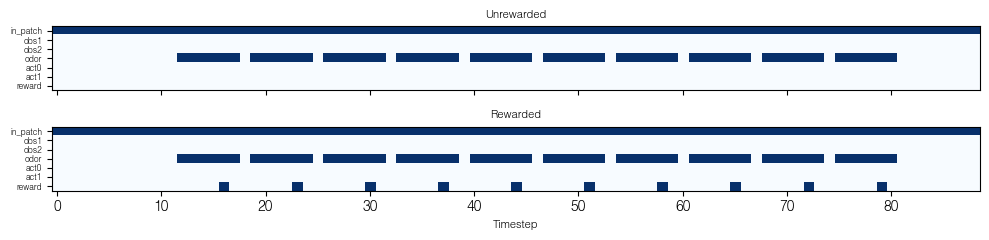

In [8]:
# ── Task / sequence parameters ───────────────────────────────────────────────
ODOR_IDX        = 3    # which obs channel carries the odor pulse
ODOR_OFFSET     = 12   # timesteps before the first odor onset (agent runs to the patch)
ODOR_ON         = 6    # duration of each odor-on block (timesteps)
ODOR_OFF        = 1    # gap between odor-on blocks (timesteps)
N_SITES         = 10   # number of reward sites per patch visit
N_STAY_THRESHOLD = 3   # min stay-actions within one odor block to count as "stayed"
INPUT_DIM       = 7    # [obs(4), prev_action(2), prev_reward(1)]
HIDDEN_SIZE     = 64

# Total sequence length covers the pre-patch lead-in plus all odor sites
T_MAX = N_SITES * (ODOR_ON + ODOR_OFF) + ODOR_OFFSET + ODOR_ON + 1
print(f"Sequence length: {T_MAX} timesteps  ({N_SITES} sites × ({ODOR_ON}+{ODOR_OFF}) + {ODOR_OFFSET} offset)")

# ── Reward patterns ───────────────────────────────────────────────────────────
# Each row is one synthetic patch: 1 = site is rewarded, 0 = unrewarded.
# We use three illustrative patterns here; add/remove rows as desired.
reward_patterns = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],   # fully unrewarded
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],   # fully rewarded
    [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],   # alternating (rewarded first)
], dtype=int)
n_patterns = len(reward_patterns)
print(f"\n{n_patterns} reward patterns defined (each {N_SITES} sites):")
for i, pat in enumerate(reward_patterns):
    print(f"  Pattern {i}: {''.join(str(v) for v in pat)}")

# ── Build input sequences ─────────────────────────────────────────────────────
# seq shape: (n_patterns, T_MAX, INPUT_DIM)
seq = np.zeros((n_patterns, T_MAX, INPUT_DIM))
seq[:, :, 0] = 1   # in_patch = 1 for the entire sequence

for p_idx, pattern in enumerate(reward_patterns):
    for site_i in range(N_SITES):
        t0 = site_i * (ODOR_ON + ODOR_OFF) + ODOR_OFFSET
        # Odor pulse: channel 3 goes high for ODOR_ON steps
        seq[p_idx, t0 : t0 + ODOR_ON, ODOR_IDX] = 1
        # Reward pulse: channel 6 goes high at step 4 of the odor-on block
        if pattern[site_i]:
            seq[p_idx, t0 + 4, 6] = 1

# Quick sanity check: visualise the two extreme patterns
fig, axes = plt.subplots(2, 1, figsize=(10, 2.5), sharex=True)
for ax, p_idx, title in zip(axes, [0, 1], ['Unrewarded', 'Rewarded']):
    ax.imshow(seq[p_idx].T, aspect='auto', cmap='Blues', interpolation='nearest')
    ax.set_yticks(range(INPUT_DIM))
    ax.set_yticklabels(['in_patch','obs1','obs2','odor','act0','act1','reward'], fontsize=6)
    ax.set_title(title, fontsize=8)
axes[-1].set_xlabel('Timestep', fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
# ── Load trajectory data and fit PCA ─────────────────────────────────────────
# We load real rollout data from network 0 to:
#   (a) initialise hidden states from a realistic pre-patch distribution, and
#   (b) fit a PCA that maps the 64-dim hidden state to interpretable PCs.
traj_path = FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS[0]
traj_data = {}
for env_idx in range(15):
    raw  = load_trajectory_data(traj_path)
    env  = parse_behavioral_data(raw[env_idx])
    for key, val in env.items():
        traj_data[key] = np.concatenate([traj_data[key], val]) if key in traj_data else val

pca = PCA()
pca.fit(traj_data['actor_hidden'])
print(f"PCA fitted on {traj_data['actor_hidden'].shape[0]:,} hidden states.")
print(f"Variance explained by first 3 PCs: {pca.explained_variance_ratio_[:3].sum()*100:.1f}%")

# ── Load checkpoint ───────────────────────────────────────────────────────────
ckpt_path  = FIXED_EXP_GRU_INITIAL_PROB_OFFSET_CHECKPOINTS[0]
restored   = checkpoints.restore_checkpoint(ckpt_dir=Path(ckpt_path).resolve(), target=train_state)
net_params = restored.params
print("Checkpoint loaded.")

PCA fitted on 300,000 hidden states.
Variance explained by first 3 PCs: 83.4%
Checkpoint loaded.


In [10]:
# ── Initialise hidden state from a realistic pre-patch state ──────────────────
# Rather than starting from zeros, we sample one hidden state from moments
# just before a real patch entry, giving the network a plausible "running"
# initial condition.  The same initial state is tiled across all patterns so
# differences in trajectory are due to reward history only.

actor_flat  = traj_data['actor_hidden'].reshape(-1, HIDDEN_SIZE)
critic_flat = traj_data['critic_hidden'].reshape(-1, HIDDEN_SIZE)
in_patch    = traj_data['agent_in_patch'].reshape(-1).astype(bool)

# Find timesteps that are the first step inside a patch (transition 0→1)
transitions    = (~in_patch[:-1]) & in_patch[1:]
pre_patch_idx  = np.where(transitions)[0] + 1   # index of first in-patch step

rng = np.random.default_rng(42)
chosen         = rng.choice(pre_patch_idx)
init_actor     = jnp.tile(jnp.array(actor_flat[chosen]),  (n_patterns, 1))   # (n_patterns, 64)
init_critic    = jnp.tile(jnp.array(critic_flat[chosen]), (n_patterns, 1))
print(f"Sampled initial hidden state from timestep {chosen} (one of {len(pre_patch_idx)} pre-patch transitions).")

# ── Batched forward pass ──────────────────────────────────────────────────────
# We step all patterns in parallel.  At each timestep the network receives
# the pre-built input x plus the previous action (updated in-place each step).
# We record: hidden states, logits, and whether the agent chose to stay (action 0).

all_hidden    = np.zeros((n_patterns, T_MAX, HIDDEN_SIZE))   # full hidden-state traces
all_logits    = np.zeros((n_patterns, T_MAX, 2))             # action logits at each step
all_stay      = np.zeros((n_patterns, T_MAX), dtype=bool)    # True = stay chosen

actor_hidden  = init_actor
critic_hidden = init_critic
last_actions  = jnp.tile(jnp.array([0., 1.]), (n_patterns, 1))  # start with "leave" action
rng_key       = jax.random.key(0)

# Track when (and whether) each pattern triggers an exit
exit_site      = np.full(n_patterns, -1, dtype=int)   # -1 = never exited
exit_time      = np.full(n_patterns, T_MAX, dtype=int)
done_mask      = np.zeros(n_patterns, dtype=bool)

t = 0
for site_i in range(N_SITES):
    t0 = site_i * (ODOR_ON + ODOR_OFF) + ODOR_OFFSET

    # ── Pre-odor timesteps: step network up to the next odor onset ──
    while t < t0:
        all_hidden[:, t] = np.array(actor_hidden)
        rng_key, noise_key = jax.random.split(rng_key)
        x = jnp.array(seq[:, t]).at[:, 4:6].set(last_actions)
        logits, _, actor_hidden, critic_hidden, _, _, _ = network.apply(
            net_params, x, actor_hidden, critic_hidden,
            rngs={'noise': noise_key})
        all_logits[:, t] = np.array(logits)
        all_stay[:, t]   = np.array(jnp.argmax(logits, axis=-1)) == 0
        last_actions     = jax.nn.one_hot(jnp.argmax(logits, axis=-1), 2)
        t += 1

    # ── Odor-on block: step network and accumulate stay counts ──────
    stay_counts = np.zeros(n_patterns, dtype=int)
    for _ in range(ODOR_ON):
        all_hidden[:, t] = np.array(actor_hidden)
        rng_key, noise_key = jax.random.split(rng_key)
        x = jnp.array(seq[:, t]).at[:, 4:6].set(last_actions)
        logits, _, actor_hidden, critic_hidden, _, _, _ = network.apply(
            net_params, x, actor_hidden, critic_hidden,
            rngs={'noise': noise_key})
        all_logits[:, t] = np.array(logits)
        chose_stay        = np.array(jnp.argmax(logits, axis=-1)) == 0
        all_stay[:, t]    = chose_stay
        stay_counts      += chose_stay.astype(int)
        last_actions      = jax.nn.one_hot(jnp.argmax(logits, axis=-1), 2)
        t += 1

    # ── Exit check: did any active pattern fail the stay threshold? ──
    # A pattern "exits" at this site if the number of stay-actions during
    # the odor-on block fell below N_STAY_THRESHOLD.
    newly_exited = (~done_mask) & (stay_counts < N_STAY_THRESHOLD)
    exit_site[newly_exited] = site_i
    exit_time[newly_exited] = t
    done_mask |= newly_exited

print("Forward pass complete.")
for p_idx, pat in enumerate(reward_patterns):
    pat_str = ''.join(str(v) for v in pat)
    es = exit_site[p_idx]
    print(f"  Pattern {p_idx} ({pat_str[:10]}): exit at site {es if es >= 0 else 'never'}")

Sampled initial hidden state from timestep 27209 (one of 4760 pre-patch transitions).
Forward pass complete.
  Pattern 0 (0000000000): exit at site never
  Pattern 1 (1111111111): exit at site never
  Pattern 2 (1010101010): exit at site never
